In [2]:
!pip install matplotlib

You should consider upgrading via the 'C:\Users\mcs\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
!pip install seaborn

You should consider upgrading via the 'C:\Users\mcs\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [6]:
!pip install opencv-python

You should consider upgrading via the 'C:\Users\mcs\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [8]:
!pip install tensorflow_hub

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\mcs\\AppData\\Local\\Programs\\Python\\Python310\\Lib\\site-packages\\~l_dtypes\\_custom_floats.cp310-win_amd64.pyd'
Consider using the `--user` option or check the permissions.

You should consider upgrading via the 'C:\Users\mcs\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.



  Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.2.0
    Uninstalling ml-dtypes-0.2.0:
      Successfully uninstalled ml-dtypes-0.2.0


In [2]:
!pip install tqdm

You should consider upgrading via the 'C:\Users\mcs\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
# standard libraries
import os 
import math
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import random
import cv2
import gc
from PIL import Image
import requests
from io import BytesIO

# tensorflow/keras libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow_hub as hub
from tqdm.keras import TqdmCallback

In [4]:
# load images
IMG_SIZE=160
BATCH_SIZE=32
FILE_PATH = 'D:\\proj\\cottonleafprediction\\dataset\\imgs'
CLASSES = os.listdir(FILE_PATH)

# read from directory
image_data = image_dataset_from_directory(
    FILE_PATH,
    label_mode='int',
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE,
    interpolation='nearest',
    labels='inferred',
    shuffle=True,
    class_names = CLASSES)


Found 4788 files belonging to 6 classes.


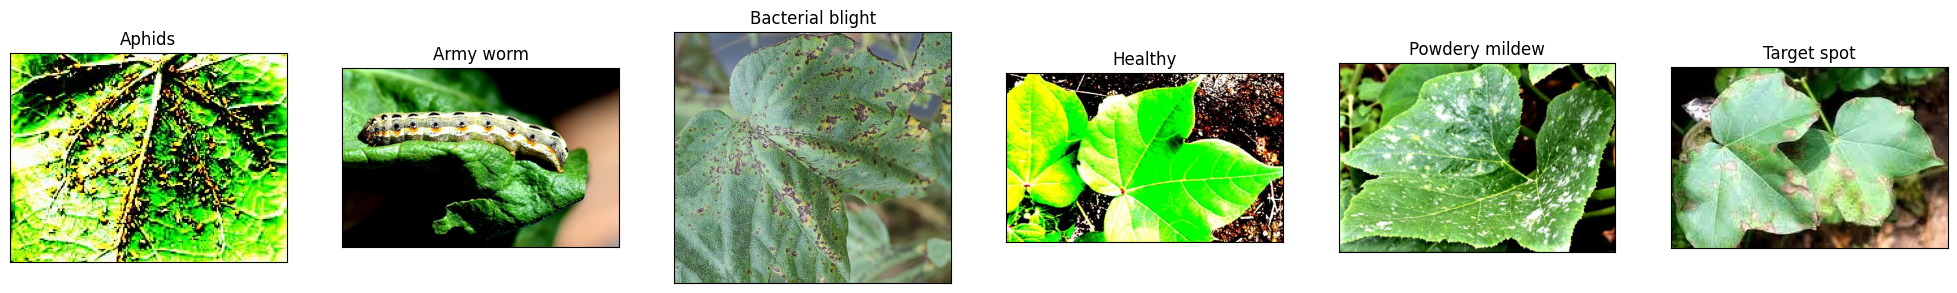

In [6]:
# generating a list with 1 random image from each class 
random_images = []
for i in enumerate(CLASSES):
    random_images.append(random.choice(glob.glob(os.path.join(FILE_PATH,CLASSES[i[0]]+'/*'))))
    
# showing each image in seperate column
n_cols = len(CLASSES)

# plot the images
plt.figure(figsize=(25, 10))
for c,r in zip(range(n_cols),random_images):
    ax = plt.subplot(1, n_cols, c + 1)
    ax.title.set_text(r.split('\\')[5])
    image = cv2.imread(r)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.xticks([])
    plt.yticks([])
plt.show()

**Data Processing**

In [7]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
ds_train = image_data.prefetch(buffer_size=AUTOTUNE)

In [8]:
# data augmentation
data_augmentation = keras.Sequential([
  layers.RandomFlip('horizontal')
  ,layers.RandomRotation(0.2)
  ,layers.RandomContrast(0.2)
  ,layers.RandomZoom(0.5,0.2)
])

In [9]:
preprocess_input = keras.applications.mobilenet_v2.preprocess_input
rescale = layers.Rescaling(1./127.5, offset=-1)

In [10]:
# create base model
IMG_SHAPE = (IMG_SIZE, IMG_SIZE) + (3,)
base_model = keras.applications.MobileNetV2(input_shape=IMG_SHAPE, include_top=False,weights='imagenet')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [11]:
image_batch, label_batch = next(iter(ds_train))
feature_batch = base_model(image_batch)
print(f"{IMG_SHAPE} converted to {feature_batch.shape}")

(160, 160, 3) converted to (32, 5, 5, 1280)


**Create Model**

In [12]:
base_model.trainable = False

In [13]:
# classification head
global_average_layer = layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(f"Feature Batch Shape: {feature_batch_average.shape} ")

# prediction layer
prediction_layer =  layers.Dense(len(CLASSES),activation='softmax')
prediction_batch = prediction_layer(feature_batch_average)
print(f"Prediction Batch Shape: {prediction_batch.shape}")

Feature Batch Shape: (32, 1280) 
Prediction Batch Shape: (32, 6)


In [14]:
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [15]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 160, 160, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_160 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 6)                   │           7,686 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
base_learning_rate = 0.0001
model.compile(optimizer=keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
epochs = 50
earlyStopping = keras.callbacks.EarlyStopping(monitor='loss',patience=3,verbose=0)
hist = model.fit(ds_train
          , epochs = epochs
          , batch_size=BATCH_SIZE
          ,shuffle=True
          ,verbose=0
          ,callbacks=[TqdmCallback(verbose=0),earlyStopping])

0epoch [00:00, ?epoch/s]

In [ ]:
acc = '{:.2%}'.format(hist.history['accuracy'][-1])
print(f"Accuracy of  {acc} in {len(hist.epoch)} epoch(s)")

In [ ]:
acc = hist.history['accuracy']
loss = hist.history['loss']
epochs_range = range(len(hist.epoch))

plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.legend(loc='lower right')
plt.title('Training Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.legend(loc='upper right')
plt.title('Training Loss')
plt.show()

In [ ]:
model.save_weights("CottonPlantDisease.h5")

In [ ]:
base_model.trainable = True

# check number of layers in base model
print("Number of layers in the base model: ", len(base_model.layers))

# fine tuning top layers
fine_tune_at = 100

# freeze layers before the *fine_tune_at* layer
for l in base_model.layers[:fine_tune_at]:
    l.trainable = False

In [ ]:
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

# model summary
model.summary()

In [ ]:
hist_finetune = model.fit(ds_train
          , epochs = epochs
          , batch_size=BATCH_SIZE
          ,shuffle=True
          ,verbose=0
          ,callbacks=[TqdmCallback(verbose=0),earlyStopping])

In [ ]:
acc_finetuned = '{:.2%}'.format(hist_finetune.history['accuracy'][-1])
print(f"After finetuning accuracy of  {acc_finetuned} in {len(hist_finetune.epoch)} epoch(s)")

In [ ]:
model.save_weights("CottonPlantDiseaseClassifier_finetuned.h5")

In [ ]:
img_url = 'https://site.extension.uga.edu/bullochag/files/2022/08/image-1.png'   
response = requests.get(img_url)
img = Image.open(BytesIO(response.content))

# saving the image to output as jpg
img_data = requests.get(img_url).content
with open('unseenImage.jpg', 'wb') as handler:
    handler.write(img_data)

# plot the image
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.title('expected class = target spot')
plt.show()

In [ ]:
image_path = '/kaggle/input/cotton-plant-disease/Cotton leaves/40 Images/Army worm/17.jpg'
unseen_img = keras.preprocessing.image.load_img(image_path,target_size=(IMG_SIZE, IMG_SIZE))
input_arr = tf.keras.preprocessing.image.img_to_array(unseen_img)
# convert single image to a batch
input_arr = np.array([input_arr])  
input_arr = input_arr.astype('float32') / 255. 

In [ ]:
# making prediction
pred = model.predict(input_arr)
# predicting class
pred_class = np.argmax(pred, axis=1)
# predicting class name
image_data.class_names.reverse()
for c in enumerate(image_data.class_names):
    if c[0] == pred_class[0]:
        print(f"Predicted Class Name: {c[1]}")
        pred_class_name = c[1]

In [ ]:
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.title('expected = target spot | predicted = '+pred_class_name)
plt.show()